## Imports & Loads

In [1]:
CANVAS_SIZE = (235, 130) # mm 

In [2]:
from stroke_generation import Hyperparameters, KNearest, PaletteColorsOnly
from datatypes import StrokeSequence, LoadBrush
from visualisation import visualize_stroke_sequence, show_np_image, resize_image
from stroke_generation import StrokeGenerationSupervisor, generate_strokes_for_layer

import numpy as np
import math

from tqdm import tqdm # progress bar


# import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance
from scipy.ndimage import gaussian_filter

from scipy.ndimage import center_of_mass
from stroke_generation import k_nearest
from visualisation import show_np_image
from skimage.segmentation import slic, mark_boundaries

## Image Pre-loading

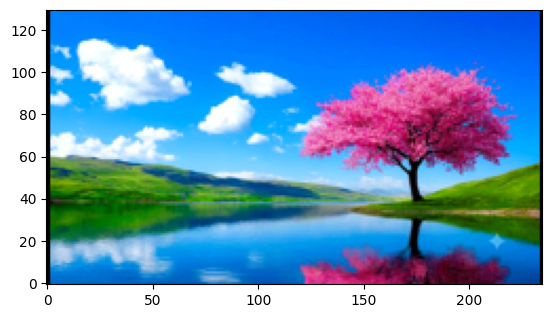

In [3]:
# 1. Load your PIL image
pil_original_image = Image.open("../images/pink-tree-ai.png").convert("RGB").transpose(Image.FLIP_TOP_BOTTOM)

enhancer = ImageEnhance.Contrast(pil_original_image)
contrast_factor = 1.2
pil_original_image = enhancer.enhance(contrast_factor)

# 2. Resize to 440x440 (assuming resize_image is defined elsewhere)
pil_resized_image = resize_image(pil_original_image, CANVAS_SIZE)

# GaussianBlur takes a 'radius' parameter. Higher radius = more blur.
# pil_blurred_image = pil_resized_image.filter(ImageFilter.GaussianBlur(radius=5))
# np_resized_blurred_image = np.array(pil_blurred_image)

# 3. Convert the original resized PIL image to a NumPy array (if still needed)
np_resized_image = np.array(pil_resized_image)
np_original_image = np.array(pil_original_image)

# Display the blurred image to verify
show_np_image(np_resized_image)

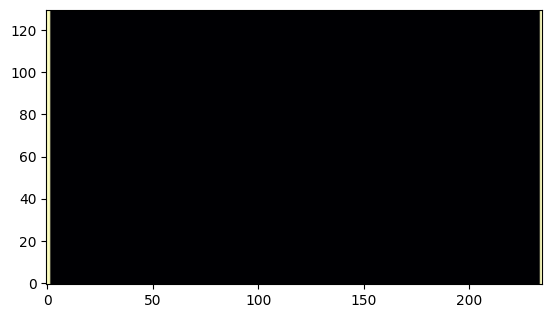

In [4]:
# 3. Create a "dummy" pure white image of the exact same original size
# This represents our "real pixels" mask BEFORE padding
mask_canvas = Image.new("L", pil_original_image.size, color=255)

# 4. Apply the exact same padding transformation to the mask canvas
# ImageOps.pad will scale and pad this mask identically to the elephant image
padded_mask_resized = ImageOps.pad(mask_canvas, CANVAS_SIZE, color=0)
np_padded_mask_resized = np.array(padded_mask_resized)

# 5. Convert mask to a 1 and 0 NumPy array
# Wherever the padded_mask is 255 (white), it's a real pixel (1). Otherwise, it's 0.
padding_mask = (np.array(padded_mask_resized) == 0).astype(np.uint8)

show_np_image(padding_mask, cmap="magma")


## Segmentation

(235, 130)
(130, 235, 3)


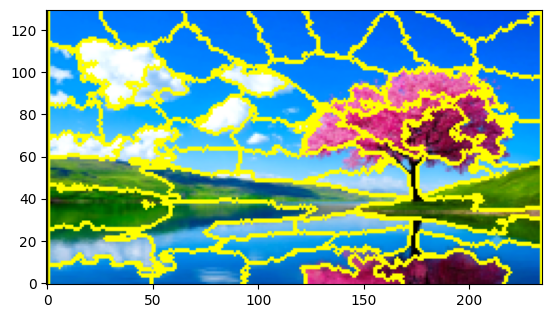

In [16]:
# 1. Run SLIC on the original image as you did
segments = slic(
    np_original_image,
    n_segments=70,
    compactness=10
)

# 2. Cast to int32 so PIL can handle it, then resize using Nearest Neighbor
segments_int32 = segments.astype(np.int32) # <--- Added this line
segments_pil = Image.fromarray(segments_int32)

resized_segments_pil = ImageOps.pad(
    segments_pil, 
    CANVAS_SIZE, 
    method=Image.Resampling.NEAREST, 
    color=0
)

print(resized_segments_pil.size)
print(np_resized_image.shape)

resized_segments = np.array(resized_segments_pil)


# 3. Calculate centroids on the NEW resized segments
for label in np.unique(resized_segments):
    # Mask out the background padding (label 0 might contain padding now)
    if label == 0: 
        continue
    centroid = center_of_mass(resized_segments == label)

show_np_image(mark_boundaries(np_resized_image, resized_segments))

## Stroke Generation

Precompute the gradient

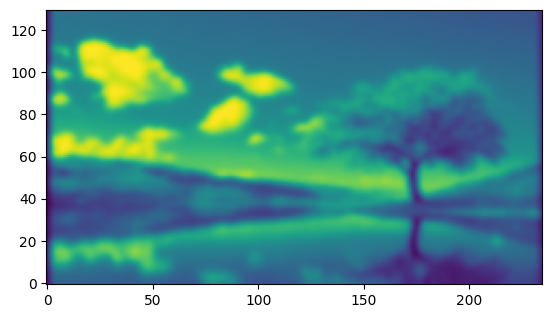

In [17]:
# # 1. Smooth the image to get a reliable, non-noisy gradient field
if np_resized_image.ndim == 3:
    gray = 0.299 * np_resized_image[:,:,0] + 0.587 * np_resized_image[:,:,1] + 0.114 * np_resized_image[:,:,2]
else:
    gray = np_resized_image.copy()

W, H, _ = np_resized_image.shape

gray_smoothed = gaussian_filter(gray, sigma=1.5)
show_np_image(gray_smoothed)
gy, gx = np.gradient(gray_smoothed)

In [18]:
Hyperparameters.COLOR_METHOD = PaletteColorsOnly()

H, W, _ = np_resized_image.shape

stroke_sequence = StrokeSequence(image_size=(W, H))
coverage_mask = ~np_padded_mask_resized

# Sort the depth thresholds ascendingly to easily find the correct bracket
stroke_generation_supervisor = StrokeGenerationSupervisor()

labels = np.unique(segments)

if type(Hyperparameters.COLOR_METHOD) == KNearest:
    np_k_nearest = k_nearest(
        np_resized_image,
        k=Hyperparameters.COLOR_METHOD.k
    )

    show_np_image(np_k_nearest)
else:
    np_k_nearest = None

# Loop through the targeted depth layer bins (Back-to-Front ordering)
for label in tqdm(labels):
    ## Choose brush-size
    segment_mask = (resized_segments == label)
    if not np.any(segment_mask):
        continue

    ## Choose brush-size based on the pre-calculated brush_size_map
    # Extract the brush size assigned to this specific segment region
    chosen_brush_size = 3
    
    # Dynamically assign it to the supervisor configuration for this layer
    stroke_generation_supervisor.brush_size = chosen_brush_size

    # Call the updated stroke generator function using dictionary unpacking (**)

    generate_strokes_for_layer(
        grad=(gy, gx),
        stroke_sequence=stroke_sequence, 
        resized_segments=resized_segments, 
        label=label, 
        np_image=np_resized_image,
        coverage_mask=coverage_mask,
        padding_mask=np_padded_mask_resized,
        stroke_generation_supervisor=stroke_generation_supervisor,
        np_k_nearest=np_k_nearest,
    )

  0%|          | 0/51 [00:00<?, ?it/s]

100%|██████████| 51/51 [00:01<00:00, 42.43it/s]


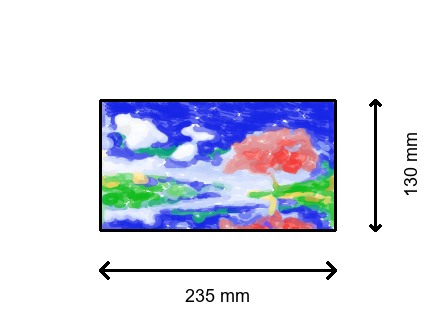

In [19]:
visualize_stroke_sequence(stroke_sequence)

In [20]:
# Test evaluation
from evalutation import evaluate

evaluate(pil_resized_image, stroke_sequence, np_padded_mask_resized)

792.8717651367188

## Stroke Reordering

In [21]:
color_buckets = {}

# sort in color buckets
for stroke in stroke_sequence.strokes:
    color_key = tuple(stroke.color)
    color_buckets.setdefault(color_key, []).append(stroke)

# color buckets to queues
stroke_sequence.strokes = []
for bucket in color_buckets.values():
    bucket.sort(key=lambda stroke: stroke.pigment, reverse=True)
    queue_count = math.ceil(len(bucket) / 20)
    bucket_queues = [[] for _ in range(queue_count)]

    for index, stroke in enumerate(bucket):
        bucket_queues[index % queue_count].append(stroke)

    # set starting value of each buckets
    for index, bucket_queue in enumerate(bucket_queues):
        bucket_queue.insert(
            0, 
            LoadBrush(
                color = bucket_queue[0].color,
                pigment = bucket_queue[0].pigment,
                deep_clean = (index == 0), # deep clean between different colors
            )
        )

    for bucket_queue in bucket_queues:
        stroke_sequence.strokes.extend(bucket_queue)

## Stroke Statistics
We counted the reason for a stroke to be declined.
Now, we will create a graph to visualize this.

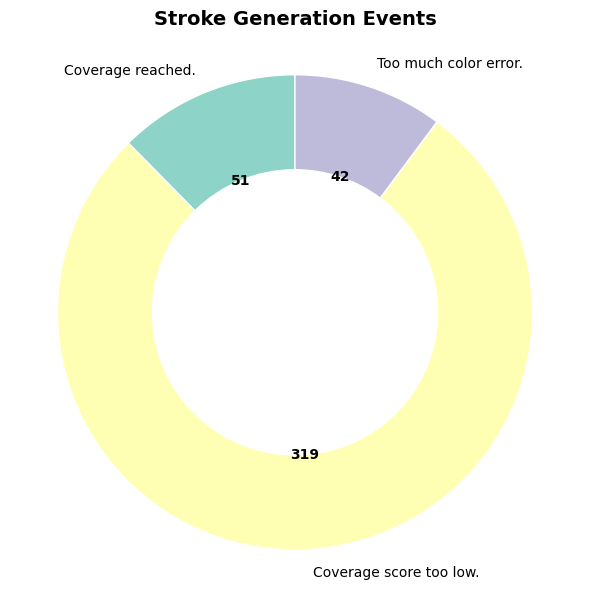

In [22]:
stroke_generation_supervisor.plot_decline_reasons()

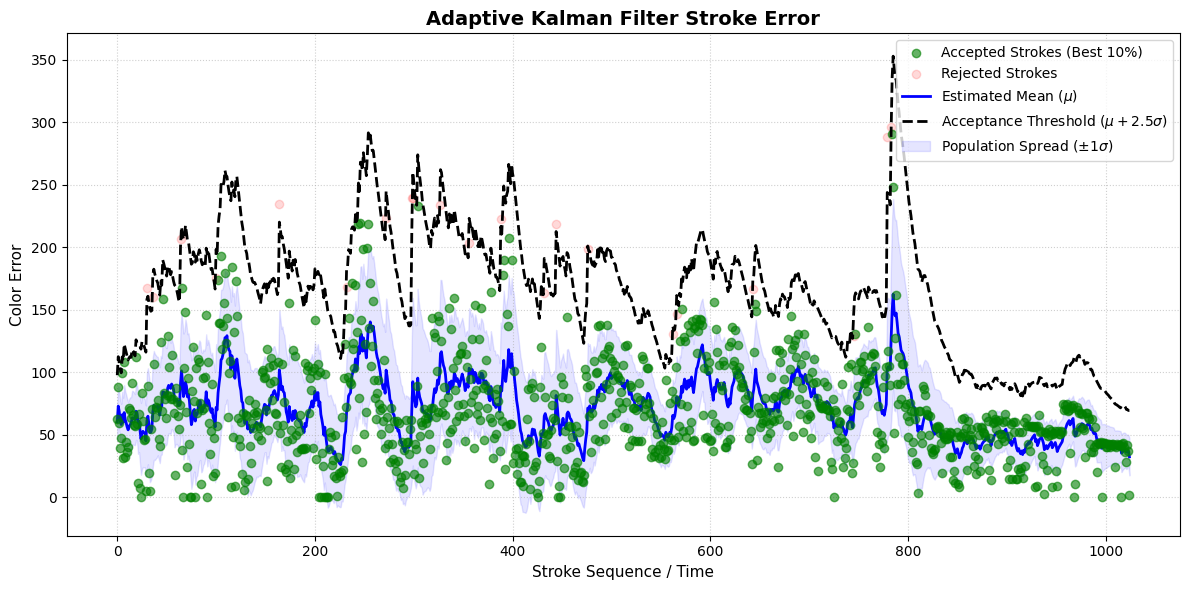

In [23]:
stroke_generation_supervisor.plot_color_error_history()

## Visualisation

Create a video from the strokes.

In [24]:
from visualisation import animate_stroke_sequence

animate_stroke_sequence(stroke_sequence, filename="render")

Start video rendering...


100%|██████████| 725/725 [00:03<00:00, 219.62it/s]


Save the strokes to a json file.

In [25]:
stroke_sequence.save_to_json("data/my_stroke_sequence.json")